In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
review = pd.read_json(r"C:\Users\songu\Downloads\Grocery_and_Gourmet_Food.jsonl\Grocery_and_Gourmet_Food.jsonl", lines = True, nrows = 100000 ) 
review

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Excellent! Yummy!,Excellent!! Yummy! Great with other foods and...,[],B00CM36GAQ,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395,0,True
1,5,Delicious!!! Yum!,Excellent! The best! I use it with my beef a...,[],B074J5WVYH,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380,0,True
2,5,"Extremely Delicious, but expensive imo",These are very tasty. They are extremely soft ...,[],B079TRNVHX,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527,1,True
3,5,Delicious!,My favorite!,[],B07194LN2Z,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614,0,True
4,5,Great taste,Great for making brownies and crinkle cookies.,[],B005CD4196,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965,7,True
...,...,...,...,...,...,...,...,...,...,...
99995,5,Delicious!,Love these flavor popcorn. And low fat. Win win.,[],B08W8Q2PTM,B08W8Q2PTM,AEFVW4PUVKW4AOPZTZVXWN4I7PEQ,2021-07-23 21:31:25.883,0,True
99996,5,Great sparkling water,"Bubly is my favorite! Prior, I used to drink L...",[],B078XXCDRS,B078XXCDRS,AEFVW4PUVKW4AOPZTZVXWN4I7PEQ,2019-06-17 16:00:09.369,0,True
99997,1,would not recommend.,artificial tasting. not a fan. would not recom...,[],B06XDL8D6B,B06XDL8D6B,AEFVW4PUVKW4AOPZTZVXWN4I7PEQ,2017-09-26 17:45:42.330,0,True
99998,5,Love that they come in four little squares,These are delicious. Love that they come in fo...,[],B013SJNIH6,B078Y5R2YJ,AEFVW4PUVKW4AOPZTZVXWN4I7PEQ,2016-06-20 16:33:16.000,0,True


In [59]:
#use parent_asin to group product together
review = review[['rating','parent_asin','user_id','timestamp']]
review.head()

,rating,parent_asin,user_id,timestamp
0,5,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395
1,5,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380
2,5,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527
3,5,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614
4,5,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965


In [60]:
review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   rating       100000 non-null  int64         
 1   parent_asin  100000 non-null  object        
 2   user_id      100000 non-null  object        
 3   timestamp    100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 3.1+ MB


In [61]:
review.isnull().sum()

rating         0
parent_asin    0
user_id        0
timestamp      0
dtype: int64

In [62]:
review.describe()

,rating,timestamp
count,100000.000000,100000
mean,4.314320,2019-09-03 20:55:35.324903424
min,1.000000,2003-10-16 10:30:16
25%,4.000000,2018-04-03 12:06:42.764999936
50%,5.000000,2020-04-23 20:27:00.225499904
75%,5.000000,2021-09-02 17:23:34.014749952
max,5.000000,2023-03-17 11:30:32.209000
std,1.188544,NaN


In [63]:
review.duplicated(subset=['user_id','parent_asin']).sum()


np.int64(2116)

In [64]:
review = review.drop_duplicates(subset=['user_id','parent_asin'])
review.duplicated(subset=['user_id','parent_asin']).sum()



np.int64(0)

In [65]:
grocery = pd.read_json(r"c:\Users\songu\Downloads\meta_Grocery_and_Gourmet_Food.jsonl\meta_Grocery_and_Gourmet_Food.jsonl", lines = True, nrows = 100000)
grocery = grocery[['title','average_rating','rating_number','description','parent_asin']]

In [66]:
grocery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   title           100000 non-null  object 
 1   average_rating  100000 non-null  float64
 2   rating_number   100000 non-null  int64  
 3   description     100000 non-null  object 
 4   parent_asin     100000 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 3.8+ MB


In [67]:
grocery.isnull().sum()

title             0
average_rating    0
rating_number     0
description       0
parent_asin       0
dtype: int64

In [68]:
grocery.duplicated('parent_asin').sum()

np.int64(0)

In [69]:
review.head()

,rating,parent_asin,user_id,timestamp
0,5,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395
1,5,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380
2,5,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527
3,5,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614
4,5,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965


In [70]:
grocery.head()

,title,average_rating,rating_number,description,parent_asin
0,Dark Roast Pure Coffee,4.7,9,[],B00NE08WM6
1,PICARAS Galletas Peruanas Bañadas en Chocolate...,4.5,12,[2 Bags of PICARAS Galletas Bañadas en Chocola...,B084Q13Q5Q
2,Chipped Beef and Gravy By Patterson's - Great ...,3.2,5,[Delicious corned beef gravy is ready when you...,B00KBRUYVM
3,Asher's Sugar Free Milk Chocolate Cordial Cher...,5.0,6,[],B0BN4PW255
4,Messmer Peppermint 25 bags (6er pack),3.5,5,[],B06X9DC27H


In [71]:
n_ratings = len(review)
n_items = review['parent_asin'].nunique()
n_users = review['user_id'].nunique()

print(f"Number of total review: {n_ratings} ")
print(f"Number of total items: {n_items}")
print(f"Number of total users: {n_users} ")
print(f"Average number of ratings per user: {round(n_ratings / n_users,2)} ")
print(f"Average number of ratings per item: {round(n_ratings / n_items,2)} ")

Number of total review: 97884 
Number of total items: 47961
Number of total users: 10459 
Average number of ratings per user: 9.36 
Average number of ratings per item: 2.04 


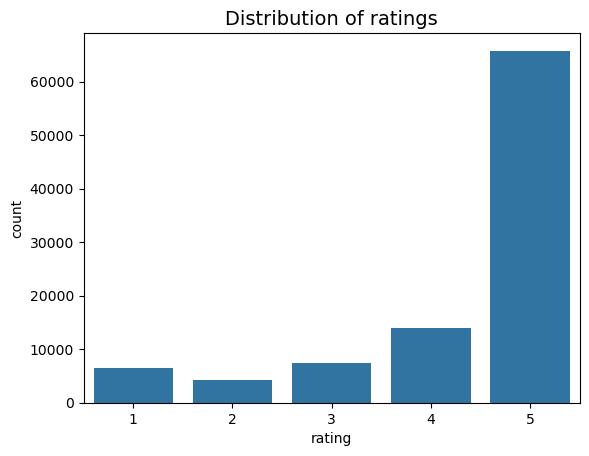

In [72]:
#Distribution of ratings 
sns.countplot(x= "rating", data = review )
plt.title("Distribution of ratings", fontsize = 14)
plt.show()

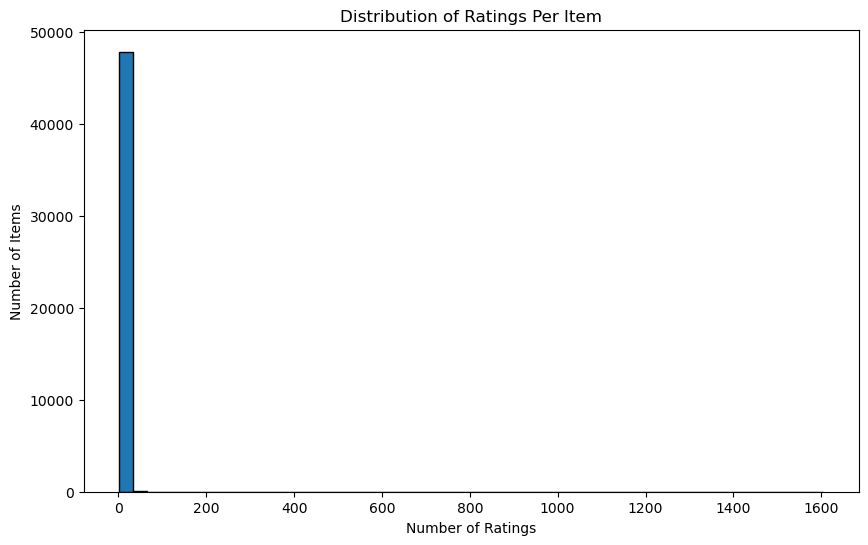

In [73]:
# This is the "ratings per item" distribution
ratings_per_item = review.groupby('parent_asin').size()

plt.figure(figsize=(10, 6))
plt.hist(ratings_per_item, bins=50, edgecolor='black')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Items')
plt.title('Distribution of Ratings Per Item')
plt.show()


In [74]:
#Pretty severe skewed data
ratings_per_item = review.groupby("parent_asin").size()
print(ratings_per_item.describe())

count    47961.000000
mean         2.040908
std         11.517894
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max       1605.000000
dtype: float64


In [75]:

user_fil = review.copy()  

iteration = 0

while True:
    iteration += 1
    
    n_users_before = user_fil['user_id'].nunique()
    n_items_before = user_fil['parent_asin'].nunique()
    
   
    item_counts = user_fil['parent_asin'].value_counts()
    valid_items = item_counts[item_counts >= 5].index
    user_fil = user_fil[user_fil['parent_asin'].isin(valid_items)]
    
   
    user_counts = user_fil['user_id'].value_counts()
    valid_users = user_counts[user_counts >= 5].index
    user_fil = user_fil[user_fil['user_id'].isin(valid_users)]
    
    n_users_after = user_fil['user_id'].nunique()
    n_items_after = user_fil['parent_asin'].nunique()
    
    print(f"Iteration {iteration}: {n_users_before}→{n_users_after} users, {n_items_before}→{n_items_after} items")
    
    if n_users_before == n_users_after and n_items_before == n_items_after:
        print("Converged!")
        break


print(f"\nMin item reviews: {user_fil['parent_asin'].value_counts().min()}")
print(f"Min user reviews: {user_fil['user_id'].value_counts().min()}")

Iteration 1: 10459→1650 users, 47961→3020 items
Iteration 2: 1650→1422 users, 3020→2096 items
Iteration 3: 1422→1391 users, 2096→1996 items
Iteration 4: 1391→1386 users, 1996→1981 items
Iteration 5: 1386→1385 users, 1981→1980 items
Iteration 6: 1385→1385 users, 1980→1979 items
Iteration 7: 1385→1385 users, 1979→1979 items
Converged!

Min item reviews: 5
Min user reviews: 5


In [76]:
print(user_fil.shape)
user_fil.head()

(18826, 4)


,rating,parent_asin,user_id,timestamp
0,5,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395
1,5,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380
2,5,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527
3,5,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614
4,5,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965


In [77]:
global_mean = round(user_fil["rating"].mean(),2)
print(f"The average score of all ratings: {global_mean}")

The average score of all ratings: 4.41


In [78]:
user_mean_ratings = user_fil.groupby("user_id")["rating"].mean()
user_mean_ratings

print(f"Mean rating per user: {round(user_mean_ratings.mean(),2)}")

Mean rating per user: 4.4


In [79]:
item_ratings = user_fil.merge(grocery, on= "parent_asin")
item_ratings 

,rating,parent_asin,user_id,timestamp,title,average_rating,rating_number,description
0,5,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380,BEN'S ORIGINAL Ready Rice Cheese Risotto Flavo...,3.7,70,[BEN'S ORIGINAL Ready Rice Cheese Risotto Rice...
1,5,B07VV7T465,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2019-03-18 03:08:03.550,"Taylors of Harrogate Green Tea with Jasmine, 2...",4.6,22535,[This distinctive green tea hails from China. ...
2,5,B00ESE0DC4,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2019-03-18 03:06:27.841,"Harney & Sons Classic Hot Cinnamon Spice Tea, ...",4.7,20100,[Harney & Sons most popular flavored tea !! Th...
3,5,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2019-01-23 01:51:58.951,"VAHDAM, Himalayan Gold Black Tea (50 Cups) | 1...",4.5,19335,[]
4,5,B08KQLCRG7,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-08-16 17:40:27.514,"Tiesta Tea - Lavender Chamomile, Loose Leaf So...",4.6,8416,"[Product Description, The BlendClose your eyes..."
...,...,...,...,...,...,...,...,...
11047,5,B09LNHZJSB,AFPYMBEAA2LML3PQKFDQSMF573NQ,2021-01-14 23:35:50.994,"King Arthur, Gluten Free Classic Pancake Mix, ...",4.8,5438,"[Better breakfasts ahead! Finally, a gluten-fr..."
11048,5,B00CF04XB0,AFPYMBEAA2LML3PQKFDQSMF573NQ,2020-03-14 14:52:59.058,Harney & Sons Earl Grey Imperial Tea Tin - Fin...,4.7,2594,[Harney & Sons Earl Grey Imperial Tea Tin - Fi...
11049,5,B0BX8J9X1Z,AFPYMBEAA2LML3PQKFDQSMF573NQ,2020-02-23 01:30:51.660,Icelandic Glacial Natural Spring Alkaline Wate...,4.7,13273,[Icelandic Glacial is a premium natural spring...
11050,5,B0BHX6XYZV,AFPYMBEAA2LML3PQKFDQSMF573NQ,2020-02-22 18:12:47.394,The Granola Bakery Maple Keto Granola Cereal |...,4.5,17715,[]


In [80]:
#How frequennt does the item get rated
item_fre = item_ratings['parent_asin'].value_counts().reset_index()
item_fre



,parent_asin,count
0,B07VV7T465,208
1,B0759B7KLH,178
2,B07GBHKW1Z,72
3,B0BVWNXZVZ,63
4,B00347UJQQ,61
...,...,...
1041,B00H6P10A6,5
1042,B07MM6439D,5
1043,B0B9G5ZQW5,5
1044,B0C5FW9LLV,5


In [81]:
#List of rating
top_list = item_fre.merge(item_ratings, on= "parent_asin")
top_list
#count = what Ive captured from 100k lines
#rating_number = total ratings of that item

,parent_asin,count,rating,user_id,timestamp,title,average_rating,rating_number,description
0,B07VV7T465,208,5,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2019-03-18 03:08:03.550,"Taylors of Harrogate Green Tea with Jasmine, 2...",4.6,22535,[This distinctive green tea hails from China. ...
1,B07VV7T465,208,5,AEQLRIQLBPN4UUHV3L5FDRZOAL2A,2022-12-13 01:53:43.230,"Taylors of Harrogate Green Tea with Jasmine, 2...",4.6,22535,[This distinctive green tea hails from China. ...
2,B07VV7T465,208,5,AFMHO73ZLBHUMB36EHB4GUFLM3SA,2022-02-09 22:42:14.510,"Taylors of Harrogate Green Tea with Jasmine, 2...",4.6,22535,[This distinctive green tea hails from China. ...
3,B07VV7T465,208,5,AF57ANFOM7CC3AXSFNHH4HGXCTFQ,2020-05-10 20:51:24.598,"Taylors of Harrogate Green Tea with Jasmine, 2...",4.6,22535,[This distinctive green tea hails from China. ...
4,B07VV7T465,208,5,AGYGYFLJQHXIH335N2ZWTRJ3KGTA,2020-05-05 21:38:50.664,"Taylors of Harrogate Green Tea with Jasmine, 2...",4.6,22535,[This distinctive green tea hails from China. ...
...,...,...,...,...,...,...,...,...,...
11047,B09QKMZ6YM,5,5,AGXDSCMRVXQX7WWB7QP7V77VILCA,2018-01-28 10:04:07.447,True Lemon Assorted Beverage Pack: (5boxes 10c...,4.5,1923,[Made from a patented process that cold-presse...
11048,B09QKMZ6YM,5,5,AHHT4PHX6BDOC63MKPNDKXMGEDYQ,2019-11-18 05:27:24.791,True Lemon Assorted Beverage Pack: (5boxes 10c...,4.5,1923,[Made from a patented process that cold-presse...
11049,B09QKMZ6YM,5,5,AEAXAJACFMXIAAH4WOHRMXPSZWFA,2014-07-15 20:48:21.000,True Lemon Assorted Beverage Pack: (5boxes 10c...,4.5,1923,[Made from a patented process that cold-presse...
11050,B09QKMZ6YM,5,5,AHIJALICVPO6SNRZZKV3ZH5FUZUA,2018-09-18 22:44:36.795,True Lemon Assorted Beverage Pack: (5boxes 10c...,4.5,1923,[Made from a patented process that cold-presse...


In [82]:
top_10 = item_ratings['title'].value_counts()[0:10]
top_10


title
Taylors of Harrogate Green Tea with Jasmine, 20 Count (Pack of 6)                                                                                                                            208
BEN'S ORIGINAL Ready Rice Cheese Risotto Flavored Rice, Easy Dinner Side, 8.5 oz Pouch (Pack of 12)                                                                                          178
BEN'S ORIGINAL Ready Rice Butter and Garlic Flavored Rice, Easy Dinner Side, 8.8 oz Pouch (Pack of 6)                                                                                         72
Jack Link's Beef Jerky, Sweet & Hot, ½ Pounder Bag - Flavorful Meat Snack, 9g of Protein and 80 Calories, Made with Premium Beef - 96 Percent Fat Free, No Added MSG or Nitrates/Nitrites     63
Slim Jim Original 'N Cheese, Original Flavor, 0.9 oz 10 ct                                                                                                                                    61
Nestle Coffee mate Coffee Cre

In [83]:
# Lowest 10
unique = top_list[['parent_asin','count', 'title', 'average_rating']].drop_duplicates(subset='parent_asin') #subset drop identical product ID
lowest_10 = unique.sort_values('average_rating').head(10)
lowest_10

,parent_asin,count,title,average_rating
3494,B07DR4DHXY,19,"SUNSPLASHERS Raspberry Lemonade, 120 Count",2.9
4738,B08827LCZD,13,OREO Green Creme Easter Chocolate Sandwich Coo...,2.9
6214,B09RP6L3W9,10,Crispy Salmon Skin Chips by GOODFISH - Tart Cr...,3.0
8323,B0057FSSCU,7,"Banner Sausage, Canned Sausage, 10.5 OZ (Pack ...",3.1
8127,B07H4X8FLF,7,Farm Sweet Organic Fruit Strip With No Added S...,3.4
8847,B0BVTRB6NP,6,"Shrewd Food Protein Puffs - High Protein, Low-...",3.4
10102,B0BS1LCBNR,5,Coffee Blenders Tea Bag Coffee - Colombian Fla...,3.5
10007,B00AMC3NK0,5,"Popchips Katy's Kettle Corn, 3.5 Ounce (Pack o...",3.5
10457,B0992FXGML,5,Flackers Organic Everything Flax & Fonio Ancie...,3.6
9081,B08FYFHL1N,6,"Chicken Chip Variety by Wilde Chips, 6 Flavors...",3.6


In [84]:
#Highest 10
highest_10 = unique.sort_values('average_rating', ascending= False ).head(10)
highest_10 

,parent_asin,count,title,average_rating
5656,B0B5WM8ZZ8,11,"Twining Tea Lavender Earl Grey, 1.41 oz (20 CO...",5.0
1129,B0C7RK6R7K,42,"Planters Mixed Nuts, Lightly Salted, 8.5 oz Ca...",5.0
8281,B09G7X8J2Q,7,"Werther's Original Caramel Hard Candy, 34.0-Ou...",5.0
10817,B08FG73LN5,5,"Simply Organic Ground Cumin Seed, Certified Or...",5.0
8505,B0BK5Y178G,7,"OLD BAY Seasoning, 24 Ounce (Pack of 6)",5.0
1212,B08QPWJYWZ,41,"Tropicana Orange Juice, Some Pulp, Homestyle, ...",4.8
10252,B08G1NVBQJ,5,Mio Berry Pomegranate Liquid Water Enhancer Dr...,4.8
8008,B0C5JYNY7N,7,Angie's BOOMCHICKAPOP Gluten Free Cheddar Chee...,4.8
3008,B08P7DZL9D,21,HERSHEY'S KISSES Silver Foils Milk Chocolate C...,4.8
8316,B07G7MX8R8,7,"Anthony's Almond Meal Flour, Unblanched, 5 lb,...",4.8


Some products have very high scores from only a few ratings, while others have slightly lower scores but from many ratings, which can make comparisons unfair.

Bayesian Average

In [85]:
list_stat = user_fil.groupby("parent_asin")["rating"].agg(["count","mean","sum"])
list_stat.head(10)

,count,mean,sum
parent_asin,,,
B00017028M,12,5.000000,60
B0005Z6ZK4,8,4.625000,37
B00099XNXS,14,4.714286,66
B00099XOXM,19,3.789474,72
B00099XPD6,8,4.625000,37
B000E6LBXK,6,4.666667,28
B000FI701Y,5,4.400000,22
B000FIUQB0,5,4.800000,24
B000FIXYCS,8,4.250000,34


In [86]:
C = list_stat["count"].mean()
M = list_stat["mean"].mean()

print(f"Average of number of ratings for a given item: {C:0.2f}")
print(f"Average rating of given item: {M:0.2f} ")

Average of number of ratings for a given item: 9.51
Average rating of given item: 4.39 


In [87]:
def bayes(ratings):
    bayesian_avg = (C * M + ratings.sum()) / (C + ratings.count())
    return round(bayesian_avg, 3)


Use bayesian average as baseline model

First, I want to split dataset base on date to test on baseline model.

In [88]:
user_fil['timestamp'] = pd.to_datetime(user_fil["timestamp"])
user_fil_sorted = user_fil.sort_values("timestamp")

latest = user_fil_sorted.groupby("user_id")['timestamp'].idxmax()

test  = user_fil_sorted.loc[latest]
train = user_fil_sorted.drop(latest)

print(test.shape)
print(train.shape)


(1385, 4)
(17441, 4)


Apply Bayesian to dataset

In [89]:
bay = train.groupby("parent_asin")["rating"].agg(bayes).reset_index()
item_stat = list_stat.merge(bay, on = "parent_asin")
item_stat

,parent_asin,count,mean,sum,rating
0,B00017028M,12,5.000000,60,4.687
1,B0005Z6ZK4,8,4.625000,37,4.468
2,B00099XNXS,14,4.714286,66,4.584
3,B00099XOXM,19,3.789474,72,4.224
4,B00099XPD6,8,4.625000,37,4.498
...,...,...,...,...,...
1974,B0CDFWB1YQ,5,4.400000,22,4.350
1975,B0CDLRTR5L,8,4.500000,36,4.407
1976,B0CF271RSQ,8,4.500000,36,4.627
1977,B0CFYXN8ZQ,7,4.285714,30,4.347


In [93]:
item_stat = item_stat.merge(grocery[["parent_asin","title"]]).drop_duplicates(subset="parent_asin")
item_stat

,parent_asin,count,mean,sum,rating,title
0,B00017028M,12,5.000000,60,4.687,"Maldon Salt, Sea Salt Flakes, 8.5 oz (240 g), ..."
12,B0005Z6ZK4,8,4.625000,37,4.468,Nutella Hazelnut Spread with Cocoa for Breakfa...
20,B00099XOXM,19,3.789474,72,4.224,"Campbell's Condensed Cream of Chicken Soup, 10..."
39,B000KOUK6A,7,5.000000,35,4.649,"Idahoan Buttery Homestyle® Mashed Potatoes, 4 ..."
46,B000Q5I6TG,6,3.833333,23,4.176,"Dole Mandarin Oranges, 23.5 Oz"
...,...,...,...,...,...,...
10965,B0C7PNCVW5,15,4.133333,62,4.371,CHIPS AHOY! Hershey's Milk Chocolate Chip Cook...
10980,B0C7RJ16K2,11,4.090909,45,4.230,TORTUGA Caribbean Coconut Rum Cake - 32 oz Rum...
10991,B0C7RK6R7K,42,4.785714,201,4.742,"Planters Mixed Nuts, Lightly Salted, 8.5 oz Ca..."
11033,B0C8Y93TRQ,11,4.818182,53,4.620,"Blue Diamond Almonds, Bold Sriracha, 6 Ounce"


Items in train: 1979
Overlap: 1046
Missing from grocery: 933
